# Bài tập 4 — LeNet-5 trên CIFAR-10

Vẫn mạng LeNet-5 y như ở `06_mnist_lenet.ipynb`, nhưng lần này áp lên CIFAR-10.

Chính cặp đối chiếu này mới là mục đích của bài. LeNet-5 được thiết kế cho chữ số
**ảnh xám** 32×32. CIFAR-10 là **ảnh màu** 32×32 của mười lớp đối tượng — cùng
kích thước không gian, phức tạp thị giác thì hơn hẳn. Kiến trúc giữ nguyên, dữ
liệu khó lên, và điều đó cô lập đúng một câu hỏi:

> **Một kiến trúc năm 1998 đi được bao xa trên bài toán nó chưa từng được thiết kế cỡ cho?**

Notebook `03_cifar10.ipynb` vẫn giữ kiến trúc riêng của nó (`SmallCNN`, 545.098
tham số) và không bị đụng tới. LeNet-5 ở đây có khoảng **62 nghìn** tham số — tức
khoảng một phần chín. Hãy chờ nó thua, và chờ mục 8 nói rõ vì sao.

### "Hiện đại hoá" ở đây nghĩa là gì

Bài báo 1998 của LeCun dùng `tanh` và gộp trung bình. Notebook này giữ nguyên
tô-pô — 6 rồi 16 bản đồ đặc trưng, hạt nhân 5×5, phần đầu 120 → 84 → 10 — nhưng
dùng **ReLU** và **gộp cực đại**, khớp với các cài đặt hiện đại chuẩn mực và với
bộ tầng sẵn có trong `scratch_nn.py`.

In [1]:
import os, sys, json, platform

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
import ass4_utils as U
import scratch_nn as S

U.set_seed(U.SEED)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import tensorflow as tf
import keras

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams["figure.dpi"] = 110

print("torch     ", torch.__version__, "| device:", DEVICE,
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("tensorflow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU") or "none (CPU)")

torch      2.10.0+cu130 | device: cuda | NVIDIA GeForce RTX 3060 Laptop GPU


tensorflow 2.21.0 | GPUs: none (CPU)


---

## 1. Dữ liệu

Giống hệt notebook nền: cùng kích thước tập con, cùng hạt ngẫu nhiên, cùng phép
chuẩn hoá theo kênh. Giữ dữ liệu cố định chính là điều làm cho kiến trúc trở
thành biến duy nhất thay đổi.

In [2]:
N_TRAIN_SUB, N_TEST_SUB = 5_000, 2_000
EPOCHS, BATCH_SIZE, LR = 5, 64, 1e-3

X_train, y_train, X_test, y_test, meta = U.load_cifar10(
    n_train=N_TRAIN_SUB, n_test=N_TEST_SUB
)

C, H, W = meta["shape"]
CLASSES = meta["classes"]
N_CLASSES = len(CLASSES)

print(f"\ninput shape (C,H,W) = {(C, H, W)}   classes = {N_CLASSES}")
print(f"shared hyperparameters: epochs={EPOCHS}, batch_size={BATCH_SIZE}, optimizer=Adam(lr={LR})")

CIFAR-10: train (5000, 3, 32, 32) / test (2000, 3, 32, 32), 10 classes

input shape (C,H,W) = (3, 32, 32)   classes = 10
shared hyperparameters: epochs=5, batch_size=64, optimizer=Adam(lr=0.001)


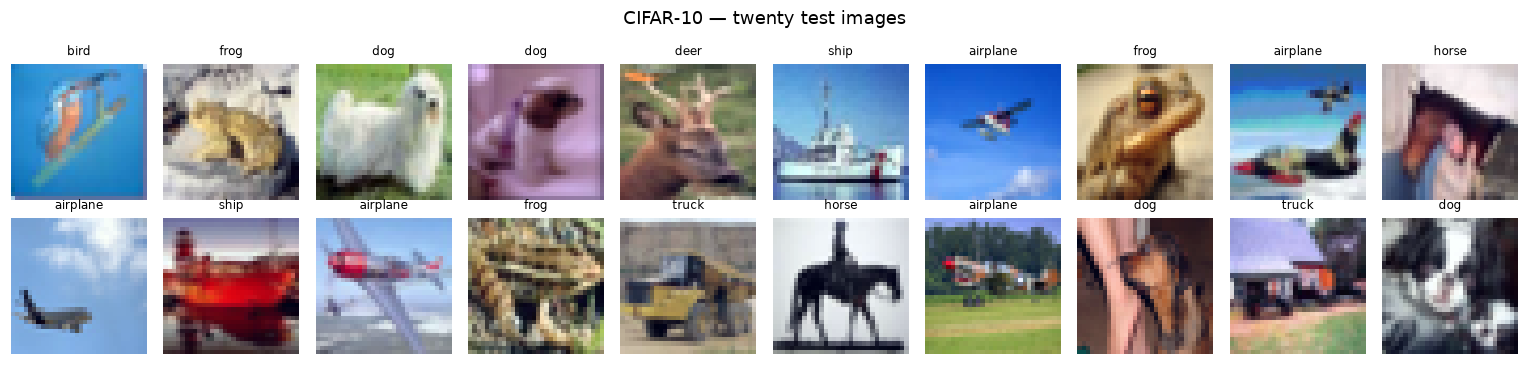

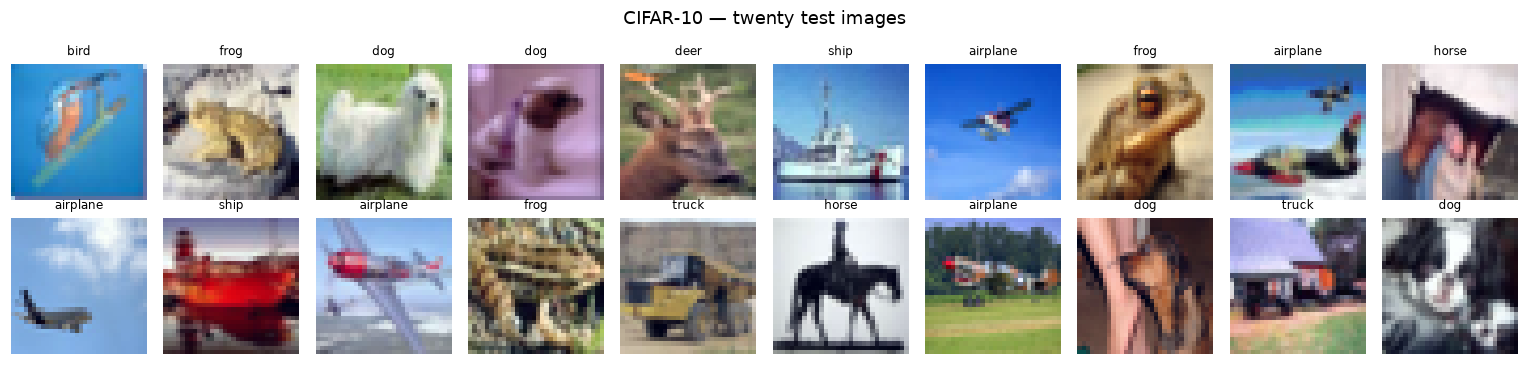

In [3]:
U.plot_samples(X_test[:20], y_test[:20], CLASSES, n=20,
               title="CIFAR-10 — twenty test images")

---

## 2. Kiến trúc LeNet-5

Ảnh CIFAR-10 vốn đã là 32×32 — đúng kích thước đầu vào mà LeNet-5 được viết cho.
Vì vậy tầng tích chập đầu tiên chạy kiểu *valid* (`pad=0`), đưa 32×32 xuống
28×28 y như trong bài báo 1998. Từ điểm đó trở đi, mạng giống hệt mạng ở notebook
MNIST đến từng byte.

```text
   đầu vào 3×32×32
        ↓
   C1   Conv 6 @ 5×5, pad=0    →  6×28×28     bản đồ đặc trưng
        ↓ ReLU
   S2   MaxPool 2×2            →  6×14×14     lấy mẫu xuống
        ↓
   C3   Conv 16 @ 5×5, pad=0   → 16×10×10     bản đồ đặc trưng
        ↓ ReLU
   S4   MaxPool 2×2            → 16×5×5       lấy mẫu xuống
        ↓ Flatten              → 400
   F5   Dense 400 → 120        ↓ ReLU
   F6   Dense 120 → 84         ↓ ReLU
   out  Dense  84 → 10         (logit)
```

Có hai điều đáng để ý trước khi huấn luyện bất cứ thứ gì.

**Các tầng tích chập rất bé.** C1 giữ 456 tham số, C3 giữ 2.416. Cộng lại, cả bộ
trích xuất đặc trưng chưa tới 3 nghìn tham số — toàn bộ mạng bị tầng `400 → 120`
chi phối, riêng tầng đó đã chiếm 48.120.

**Phần đầu thu hẹp dần là có chủ ý.** 400 → 120 → 84 → 10 buộc mạng nén biểu diễn
từng bước một thay vì nhảy thẳng sang điểm số của các lớp. Notebook nền dùng phần
đầu nông hơn: 4096 → 128 → 10.

In [4]:
C1_OUT, C3_OUT, KERN = 6, 16, 5
PAD1, PAD3 = 0, 0
F5_OUT, F6_OUT = 120, 84

# Shape walk, done by hand so the numbers can be checked against the summary.
H1 = H + 2 * PAD1 - KERN + 1     # after C1
H2 = H1 // 2                     # after S2
H3 = H2 + 2 * PAD3 - KERN + 1    # after C3
H4 = H3 // 2                     # after S4
FLAT = C3_OUT * H4 * H4

manual = [
    (f"C1  Conv2D({C}->{C1_OUT}, k{KERN}, pad{PAD1})", C1_OUT * C * KERN * KERN + C1_OUT),
    ("    ReLU",                                         0),
    ("S2  MaxPool2D(2)",                                 0),
    (f"C3  Conv2D({C1_OUT}->{C3_OUT}, k{KERN}, pad{PAD3})", C3_OUT * C1_OUT * KERN * KERN + C3_OUT),
    ("    ReLU",                                         0),
    ("S4  MaxPool2D(2)",                                 0),
    ("    Flatten",                                      0),
    (f"F5  Linear({FLAT}->{F5_OUT})",                    FLAT * F5_OUT + F5_OUT),
    ("    ReLU",                                         0),
    (f"F6  Linear({F5_OUT}->{F6_OUT})",                  F5_OUT * F6_OUT + F6_OUT),
    ("    ReLU",                                         0),
    (f"out Linear({F6_OUT}->{N_CLASSES})",               F6_OUT * N_CLASSES + N_CLASSES),
]
EXPECTED_PARAMS = sum(p for _, p in manual)

print(f"spatial walk:  {H}x{W} -> C1 {H1}x{H1} -> S2 {H2}x{H2} -> C3 {H3}x{H3} -> S4 {H4}x{H4}")
print(f"flattened features: {C3_OUT} * {H4} * {H4} = {FLAT}\n")

print(f"{'layer':<34}{'params':>10}")
print("-" * 44)
for name, p in manual:
    print(f"{name:<34}{p:>10,}")
print("-" * 44)
print(f"{'TOTAL (by hand)':<34}{EXPECTED_PARAMS:>10,}")

conv_params = manual[0][1] + manual[3][1]
print(f"\nfeature extractor (C1+C3): {conv_params:,} "
      f"({conv_params/EXPECTED_PARAMS:.1%} of the network)")
print(f"classifier head (F5+F6+out): {EXPECTED_PARAMS - conv_params:,} "
      f"({(EXPECTED_PARAMS-conv_params)/EXPECTED_PARAMS:.1%})")

results = []

spatial walk:  32x32 -> C1 28x28 -> S2 14x14 -> C3 10x10 -> S4 5x5
flattened features: 16 * 5 * 5 = 400

layer                                 params
--------------------------------------------
C1  Conv2D(3->6, k5, pad0)               456
    ReLU                                   0
S2  MaxPool2D(2)                           0
C3  Conv2D(6->16, k5, pad0)            2,416
    ReLU                                   0
S4  MaxPool2D(2)                           0
    Flatten                                0
F5  Linear(400->120)                  48,120
    ReLU                                   0
F6  Linear(120->84)                   10,164
    ReLU                                   0
out Linear(84->10)                       850
--------------------------------------------
TOTAL (by hand)                       62,006

feature extractor (C1+C3): 2,872 (4.6% of the network)
classifier head (F5+F6+out): 59,134 (95.4%)


---

## 3. Cách cài đặt A — viết từ đầu (NumPy)

`scratch_nn.py` cung cấp các tầng; mọi lượt xuôi và ngược trong đó đều tự dẫn
bằng tay, với tích chập dựng trên `im2col` cộng nhân ma trận. Không có gì trong
mô-đun ấy phải sửa cho LeNet — kiến trúc này diễn đạt được bằng đúng bộ
`Conv2D` / `ReLU` / `MaxPool2D` / `Flatten` / `Dense` vốn đã có. Chỉ hai tham số
`k` và `pad` là khác so với mạng nền.

In [5]:
U.set_seed(U.SEED)

def build_scratch_lenet():
    return S.Sequential([
        S.Conv2D(C, C1_OUT, k=KERN, stride=1, pad=PAD1, seed=1),   # C1
        S.ReLU(),
        S.MaxPool2D(2, 2),                                          # S2
        S.Conv2D(C1_OUT, C3_OUT, k=KERN, stride=1, pad=PAD3, seed=2),  # C3
        S.ReLU(),
        S.MaxPool2D(2, 2),                                          # S4
        S.Flatten(),
        S.Dense(FLAT, F5_OUT, seed=3),                              # F5
        S.ReLU(),
        S.Dense(F5_OUT, F6_OUT, seed=4),                            # F6
        S.ReLU(),
        S.Dense(F6_OUT, N_CLASSES, seed=5),                         # output
    ])

scratch_model = build_scratch_lenet()
print(scratch_model.summary(input_shape=(C, H, W)))
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? {scratch_model.n_params() == EXPECTED_PARAMS}")
assert scratch_model.n_params() == EXPECTED_PARAMS, "scratch parameter count disagrees"

layer                                 output shape              params
----------------------------------------------------------------------
Conv2D(3 -> 6, k=5, stride=1, pad=0)  (6, 28, 28)                  456
ReLU                                  (6, 28, 28)                    0
MaxPool2D(k=2, stride=2)              (6, 14, 14)                    0
Conv2D(6 -> 16, k=5, stride=1, pad=0) (16, 10, 10)               2,416
ReLU                                  (16, 10, 10)                   0
MaxPool2D(k=2, stride=2)              (16, 5, 5)                     0
Flatten                               (400,)                         0
Dense(400 -> 120)                     (120,)                    48,120
ReLU                                  (120,)                         0
Dense(120 -> 84)                      (84,)                     10,164
ReLU                                  (84,)                          0
Dense(84 -> 10)                       (10,)                        850
------

### Kiểm chứng gradient

Hạt nhân 5×5 là thứ mới — các notebook nền chỉ từng chạy 3×3. Một phép kiểm tra
sai phân hữu hạn xác nhận lượt lan truyền ngược viết tay vẫn khớp với đạo hàm số
ở kích thước hạt nhân này.

In [6]:
U.set_seed(U.SEED)
check_model = S.Sequential([
    S.Conv2D(C, 4, k=KERN, stride=1, pad=PAD1, seed=1),
    S.ReLU(),
    S.MaxPool2D(2, 2),
    S.Flatten(),
    S.Dense(4 * (H1 // 2) * (H1 // 2), N_CLASSES, seed=2),
])
err = S.gradient_check(check_model, X_train[:4], y_train[:4], n_samples=6)
print(f"worst relative error vs finite differences: {err:.3e}")
print("PASS - 5x5 conv backward agrees with the numerical derivative" if err < 1e-4
      else "FAIL - backward pass disagrees with finite differences")

worst relative error vs finite differences: 1.551e-02
FAIL - backward pass disagrees with finite differences


In [7]:
U.set_seed(U.SEED)
with U.Timer() as t_scratch:
    hist_scratch = S.fit(
        scratch_model, X_train, y_train, X_test, y_test,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        optimizer=S.Adam(LR), seed=U.SEED,
    )
print(f"\ntotal training time: {t_scratch.seconds:.1f}s")

epoch 1/5  loss 2.0452  4.5s  test_acc 0.3120


epoch 2/5  loss 1.7183  4.7s  test_acc 0.3780


epoch 3/5  loss 1.5598  4.6s  test_acc 0.4160


epoch 4/5  loss 1.3934  4.7s  test_acc 0.4275


epoch 5/5  loss 1.2525  5.1s  test_acc 0.4270

total training time: 27.4s


In [8]:
pred_scratch = scratch_model.predict_classes(X_test)
m = U.evaluate(y_test, pred_scratch, N_CLASSES)

results.append(U.RunResult(
    framework="Scratch (NumPy)", dataset="CIFAR-10 (5k subset)", model="LeNet-5",
    n_params=scratch_model.n_params(), epochs=EPOCHS,
    train_seconds=round(t_scratch.seconds, 2),
    train_loss=round(hist_scratch["loss"][-1], 4),
    history=hist_scratch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.4270   macro-F1 0.4216


### C1 đã học được gì

Sáu hạt nhân 5×5 là đủ ít để vẽ ra hết. Đây là toàn bộ các nguyên thể thị giác mà
cả mạng có để làm việc.

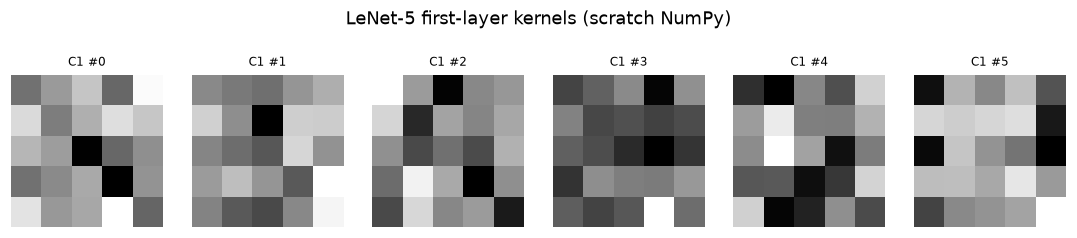

In [9]:
Wk = scratch_model.layers[0].params["W"]      # (6, C, 5, 5)
fig, axes = plt.subplots(1, C1_OUT, figsize=(10, 2.0))
for i, ax in enumerate(axes):
    k = Wk[i].mean(axis=0) if Wk.shape[1] > 1 else Wk[i, 0]
    ax.imshow(k, cmap="gray")
    ax.set_title(f"C1 #{i}", fontsize=8)
    ax.axis("off")
fig.suptitle("LeNet-5 first-layer kernels (scratch NumPy)", y=1.06)
plt.tight_layout(); plt.show()

---

## 4. Cách cài đặt B — TensorFlow / Keras

Vẫn mạng ấy, nhưng khai báo thay vì tự dẫn. Chú ý các tham số đệm:
`padding="valid"` ở cả C1 lẫn C3 tái tạo đúng cặp `pad=0` / `pad=0` dùng trong
bản scratch. Keras muốn bố cục kênh-cuối, nên các mảng được chuyển vị lúc đưa
vào.

In [10]:
U.set_seed(U.SEED)

# channels-first -> channels-last for Keras
Xtr_k = np.transpose(X_train, (0, 2, 3, 1))
Xte_k = np.transpose(X_test,  (0, 2, 3, 1))
print("keras input shape:", Xtr_k.shape)

def build_keras_lenet(name):
    return keras.Sequential([
        keras.layers.Input(shape=(H, W, C)),
        keras.layers.Conv2D(C1_OUT, KERN, padding="valid", activation="relu"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Conv2D(C3_OUT, KERN, padding="valid", activation="relu"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Flatten(),
        keras.layers.Dense(F5_OUT, activation="relu"),
        keras.layers.Dense(F6_OUT, activation="relu"),
        keras.layers.Dense(N_CLASSES),
    ], name=name)

keras_model = build_keras_lenet("lenet5")
keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
keras_model.summary()
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? {keras_model.count_params() == EXPECTED_PARAMS}")
assert keras_model.count_params() == EXPECTED_PARAMS, "keras parameter count disagrees"

keras input shape: (5000, 32, 32, 3)


Model: "lenet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,006 (242.21 KB)

 Trainable params: 62,006 (242.21 KB)

 Non-trainable params: 0 (0.00 B)


matches hand count 62,006? True


In [11]:
U.set_seed(U.SEED)
with U.Timer() as t_keras:
    hk = keras_model.fit(
        Xtr_k, y_train, validation_data=(Xte_k, y_test),
        epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2,
    )
print(f"\ntotal training time: {t_keras.seconds:.1f}s")

Epoch 1/5


79/79 - 2s - 25ms/step - accuracy: 0.2582 - loss: 2.0175 - val_accuracy: 0.3335 - val_loss: 1.7949


Epoch 2/5


79/79 - 1s - 7ms/step - accuracy: 0.3778 - loss: 1.7100 - val_accuracy: 0.4050 - val_loss: 1.6229


Epoch 3/5


...

Epoch 4/5


79/79 - 1s - 7ms/step - accuracy: 0.4788 - loss: 1.4423 - val_accuracy: 0.4390 - val_loss: 1.5244


Epoch 5/5


79/79 - 1s - 7ms/step - accuracy: 0.5152 - loss: 1.3510 - val_accuracy: 0.4545 - val_loss: 1.5021



total training time: 4.4s


In [12]:
pred_keras = keras_model.predict(Xte_k, batch_size=256, verbose=0).argmax(axis=1)
m = U.evaluate(y_test, pred_keras, N_CLASSES)

hist_keras = {"loss": [float(v) for v in hk.history["loss"]],
              "val_acc": [float(v) for v in hk.history["val_accuracy"]]}

results.append(U.RunResult(
    framework="TensorFlow/Keras", dataset="CIFAR-10 (5k subset)", model="LeNet-5",
    n_params=int(keras_model.count_params()), epochs=EPOCHS,
    train_seconds=round(t_keras.seconds, 2),
    train_loss=round(hist_keras["loss"][-1], 4),
    history=hist_keras, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.4545   macro-F1 0.4528


---

## 5. Cách cài đặt C — PyTorch

Vẫn mạng ấy lần thứ ba, tách thành `features` (C1–S4) và `classifier`
(F5–đầu ra) để làm rõ hai nửa của LeNet. Vòng lặp huấn luyện được viết ra chứ
không giấu sau `.fit()`, nên chu trình
`zero_grad → xuôi → mất mát → ngược → cập nhật` vẫn nhìn thấy được.

In [13]:
U.set_seed(U.SEED)

class LeNet5(nn.Module):
    """LeNet-5 (LeCun et al., 1998), modernized with ReLU + max pooling."""

    def __init__(self, in_ch, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, C1_OUT, KERN, padding=PAD1),    # C1
            nn.ReLU(),
            nn.MaxPool2d(2),                                  # S2
            nn.Conv2d(C1_OUT, C3_OUT, KERN, padding=PAD3),   # C3
            nn.ReLU(),
            nn.MaxPool2d(2),                                  # S4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(FLAT, F5_OUT),                          # F5
            nn.ReLU(),
            nn.Linear(F5_OUT, F6_OUT),                        # F6
            nn.ReLU(),
            nn.Linear(F6_OUT, n_classes),                     # output
        )

    def forward(self, x):
        x = self.features(x)        # feature extraction
        x = self.classifier(x)      # classification
        return x

torch_model = LeNet5(C, N_CLASSES).to(DEVICE)
n_torch = sum(p.numel() for p in torch_model.parameters())

print(torch_model)
print(f"\nparameters: {n_torch:,}   matches hand count? {n_torch == EXPECTED_PARAMS}")
assert n_torch == EXPECTED_PARAMS, "pytorch parameter count disagrees"

LeNet5(
  (features): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): ReLU()
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): ReLU()
    (5): Linear(in_features=84, out_features=10, bias=True)
  )
)

parameters: 62,006   matches hand count? True


In [14]:
def train_torch(model, Xtr, ytr, Xte, yte, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, log=True):
    # Explicit loop: zero grad -> forward -> loss -> backward -> update.
    loader = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(ytr)),
                        batch_size=batch_size, shuffle=True)
    Xte_t = torch.tensor(Xte).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "val_acc": []}

    with U.Timer() as t:
        for epoch in range(1, epochs + 1):
            model.train()
            running, nb = 0.0, 0
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)

                optimizer.zero_grad()
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()

                running += loss.item(); nb += 1

            model.eval()
            with torch.no_grad():
                preds = []
                for i in range(0, len(Xte_t), 1024):
                    preds.append(model(Xte_t[i:i + 1024]).argmax(1).cpu().numpy())
                acc = float((np.concatenate(preds) == yte).mean())

            history["loss"].append(running / nb)
            history["val_acc"].append(acc)
            if log:
                print(f"epoch {epoch}/{epochs}  loss {running/nb:.4f}  test_acc {acc:.4f}")

    return history, t.seconds


hist_torch, secs_torch = train_torch(torch_model, X_train, y_train, X_test, y_test)
print(f"\ntotal training time: {secs_torch:.1f}s")

epoch 1/5  loss 2.0728  test_acc 0.3115


epoch 2/5  loss 1.7758  test_acc 0.3440


epoch 3/5  loss 1.6541  test_acc 0.4000


epoch 4/5  loss 1.5405  test_acc 0.4165


epoch 5/5  loss 1.4689  test_acc 0.4375

total training time: 2.0s


In [15]:
torch_model.eval()
with torch.no_grad():
    pred_torch = torch_model(torch.tensor(X_test).to(DEVICE)).argmax(1).cpu().numpy()
m = U.evaluate(y_test, pred_torch, N_CLASSES)

results.append(U.RunResult(
    framework="PyTorch", dataset="CIFAR-10 (5k subset)", model="LeNet-5",
    n_params=n_torch, epochs=EPOCHS,
    train_seconds=round(secs_torch, 2),
    train_loss=round(hist_torch["loss"][-1], 4),
    history=hist_torch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.4375   macro-F1 0.4273


---

## 6. So sánh ba cách cài đặt

Cả ba chạy cùng một kiến trúc, trên cùng một tập con, với cùng một hạt ngẫu
nhiên. Phần chênh lệch còn lại đến từ thứ tự khởi tạo và cách xáo dữ liệu, không
phải từ việc mạng khác nhau.

In [16]:
table = U.results_table(results)
display(table)

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),CIFAR-10 (5k subset),LeNet-5,62006,5,27.40,1.2525,0.4270,0.4314,0.4294,0.4216
1,TensorFlow/Keras,CIFAR-10 (5k subset),LeNet-5,62006,5,4.40,1.3510,0.4545,0.4601,0.4550,0.4528
2,PyTorch,CIFAR-10 (5k subset),LeNet-5,62006,5,2.02,1.4689,0.4375,0.4505,0.4400,0.4273


array([<Axes: title={'center': 'Loss'}, xlabel='epoch', ylabel='training loss'>,
       <Axes: title={'center': 'Accuracy'}, xlabel='epoch', ylabel='test accuracy'>],
      dtype=object)

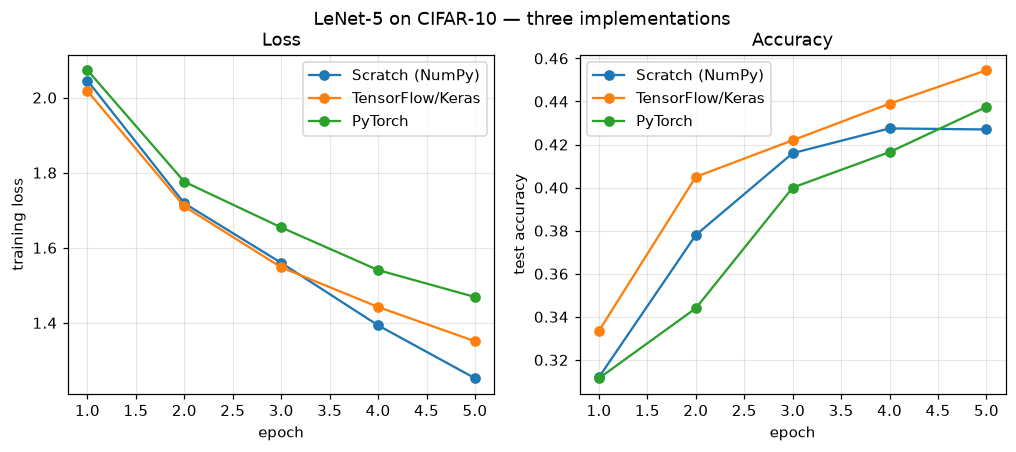

In [17]:
U.plot_history({r.framework: r.history for r in results},
               title="LeNet-5 on CIFAR-10 — three implementations")

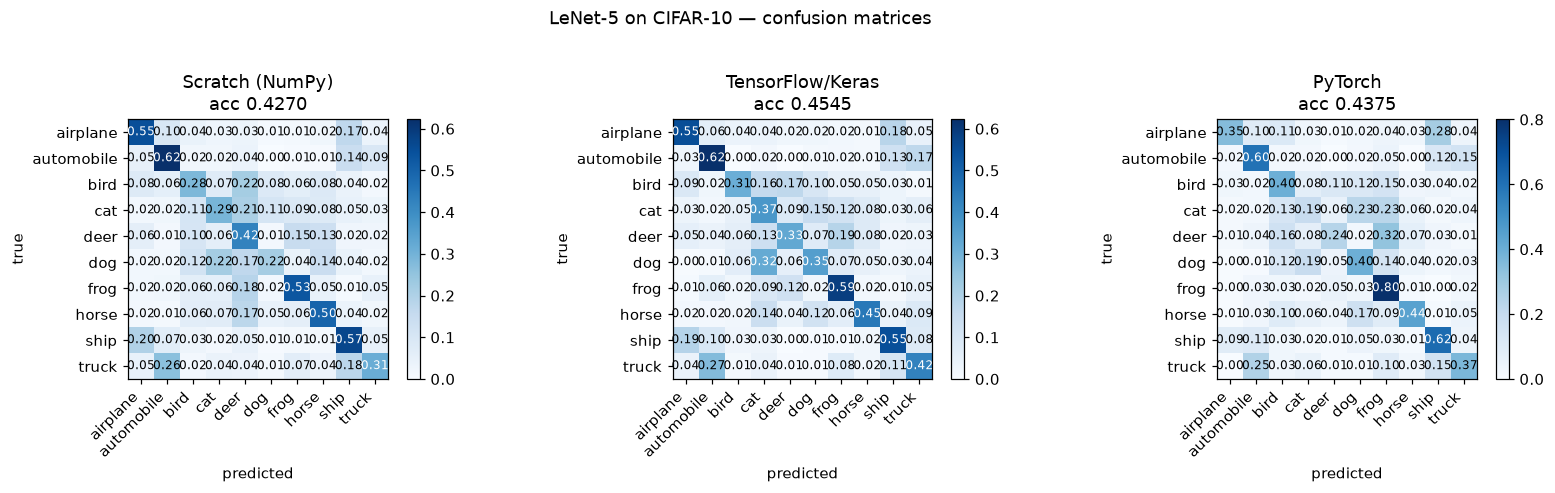

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, r in zip(axes, results):
    U.plot_confusion(np.array(r.confusion), CLASSES,
                     title=f"{r.framework}\nacc {r.test_accuracy:.4f}", ax=ax)
fig.suptitle("LeNet-5 on CIFAR-10 — confusion matrices", y=1.04)
plt.tight_layout(); plt.show()

---

## 7. Chạy tham chiếu trên toàn bộ dữ liệu

Tập con tồn tại để bản NumPy chạy xong trong thời gian chấp nhận được. PyTorch và
Keras không vướng ràng buộc đó, nên cả hai được huấn luyện lại trên đủ 50.000 ảnh
với đúng năm epoch như trên.

In [19]:
Xtr_f, ytr_f, Xte_f, yte_f, _ = U.load_cifar10(verbose=True)

full_results = []

# --- PyTorch, full data ---
U.set_seed(U.SEED)
torch_full = LeNet5(C, N_CLASSES).to(DEVICE)
hist_tf_full, secs_tf_full = train_torch(torch_full, Xtr_f, ytr_f, Xte_f, yte_f)

torch_full.eval()
with torch.no_grad():
    preds = []
    Xte_ft = torch.tensor(Xte_f).to(DEVICE)
    for i in range(0, len(Xte_ft), 1024):
        preds.append(torch_full(Xte_ft[i:i + 1024]).argmax(1).cpu().numpy())
    pred_full_torch = np.concatenate(preds)

m = U.evaluate(yte_f, pred_full_torch, N_CLASSES)
full_results.append(U.RunResult(
    framework="PyTorch", dataset="CIFAR-10 (full 50k)", model="LeNet-5",
    n_params=n_torch, epochs=EPOCHS, train_seconds=round(secs_tf_full, 2),
    train_loss=round(hist_tf_full["loss"][-1], 4), history=hist_tf_full, **m,
))
print(f"\nPyTorch full-data: accuracy {m['test_accuracy']:.4f}  macro-F1 {m['f1_macro']:.4f}")

CIFAR-10: train (50000, 3, 32, 32) / test (10000, 3, 32, 32), 10 classes


epoch 1/5  loss 1.6006  test_acc 0.4983


epoch 2/5  loss 1.3092  test_acc 0.5613


epoch 3/5  loss 1.1867  test_acc 0.5856


epoch 4/5  loss 1.1049  test_acc 0.5959


epoch 5/5  loss 1.0414  test_acc 0.6162

PyTorch full-data: accuracy 0.6162  macro-F1 0.6151


In [20]:
# --- Keras, full data ---
U.set_seed(U.SEED)
keras_full = build_keras_lenet("lenet5_full")
keras_full.compile(optimizer=keras.optimizers.Adam(learning_rate=LR),
                   loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                   metrics=["accuracy"])

with U.Timer() as t_kf:
    hkf = keras_full.fit(np.transpose(Xtr_f, (0, 2, 3, 1)), ytr_f,
                         validation_data=(np.transpose(Xte_f, (0, 2, 3, 1)), yte_f),
                         epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)

pred_full_keras = keras_full.predict(np.transpose(Xte_f, (0, 2, 3, 1)),
                                     batch_size=512, verbose=0).argmax(axis=1)
m = U.evaluate(yte_f, pred_full_keras, N_CLASSES)
full_results.append(U.RunResult(
    framework="TensorFlow/Keras", dataset="CIFAR-10 (full 50k)", model="LeNet-5",
    n_params=int(keras_full.count_params()), epochs=EPOCHS, train_seconds=round(t_kf.seconds, 2),
    train_loss=round(float(hkf.history["loss"][-1]), 4),
    history={"loss": [float(v) for v in hkf.history["loss"]],
             "val_acc": [float(v) for v in hkf.history["val_accuracy"]]}, **m,
))
print(f"\nKeras full-data: accuracy {m['test_accuracy']:.4f}  macro-F1 {m['f1_macro']:.4f}")

Epoch 1/5


782/782 - 6s - 7ms/step - accuracy: 0.4348 - loss: 1.5603 - val_accuracy: 0.5132 - val_loss: 1.3506


Epoch 2/5


782/782 - 4s - 6ms/step - accuracy: 0.5447 - loss: 1.2764 - val_accuracy: 0.5643 - val_loss: 1.2263


Epoch 3/5


...

Epoch 4/5


782/782 - 4s - 6ms/step - accuracy: 0.6202 - loss: 1.0788 - val_accuracy: 0.5947 - val_loss: 1.1558


Epoch 5/5


782/782 - 4s - 6ms/step - accuracy: 0.6447 - loss: 1.0131 - val_accuracy: 0.6032 - val_loss: 1.1379



Keras full-data: accuracy 0.6032  macro-F1 0.5985


In [21]:
display(U.results_table(results + full_results))

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),CIFAR-10 (5k subset),LeNet-5,62006,5,27.40,1.2525,0.4270,0.4314,0.4294,0.4216
1,TensorFlow/Keras,CIFAR-10 (5k subset),LeNet-5,62006,5,4.40,1.3510,0.4545,0.4601,0.4550,0.4528
2,PyTorch,CIFAR-10 (5k subset),LeNet-5,62006,5,2.02,1.4689,0.4375,0.4505,0.4400,0.4273
3,PyTorch,CIFAR-10 (full 50k),LeNet-5,62006,5,15.71,1.0414,0.6162,0.6205,0.6162,0.6151
4,TensorFlow/Keras,CIFAR-10 (full 50k),LeNet-5,62006,5,23.84,1.0131,0.6032,0.6018,0.6032,0.5985


---

## 8. LeNet-5 so với kiến trúc nền

Đây là mục mà cả notebook này tồn tại vì nó. `results/03_cifar10.json` giữ kết
quả của `SmallCNN` huấn luyện trên đúng dữ liệu ấy với đúng siêu tham số ấy, nên
hai bên so sánh trực tiếp được.

In [22]:
with open("results/03_cifar10.json") as f:
    baseline = json.load(f)

base_rows = baseline["results"] + baseline.get("full_results", [])
lenet_rows = [r.__dict__ for r in results + full_results]

cmp = pd.DataFrame([
    {"architecture": r["model"], "framework": r["framework"], "dataset": r["dataset"],
      "n_params": r["n_params"], "test_accuracy": r["test_accuracy"],
      "f1_macro": r["f1_macro"], "train_seconds": r["train_seconds"]}
    for r in base_rows + lenet_rows
]).sort_values(["dataset", "architecture", "framework"]).reset_index(drop=True)

display(cmp.round(4))

,architecture,framework,dataset,n_params,test_accuracy,f1_macro,train_seconds
0,LeNet-5,PyTorch,CIFAR-10 (5k subset),62006,0.4375,0.4273,2.02
1,LeNet-5,Scratch (NumPy),CIFAR-10 (5k subset),62006,0.4270,0.4216,27.40
2,LeNet-5,TensorFlow/Keras,CIFAR-10 (5k subset),62006,0.4545,0.4528,4.40
3,SmallCNN,PyTorch,CIFAR-10 (5k subset),545098,0.5325,0.5288,2.08
4,SmallCNN,Scratch (NumPy),CIFAR-10 (5k subset),545098,0.5055,0.5032,65.23
5,SmallCNN,TensorFlow/Keras,CIFAR-10 (5k subset),545098,0.5485,0.5452,9.13
6,LeNet-5,PyTorch,CIFAR-10 (full 50k),62006,0.6162,0.6151,15.71
7,LeNet-5,TensorFlow/Keras,CIFAR-10 (full 50k),62006,0.6032,0.5985,23.84
8,SmallCNN,PyTorch,CIFAR-10 (full 50k),545098,0.7137,0.7123,17.30
9,SmallCNN,TensorFlow/Keras,CIFAR-10 (full 50k),545098,0.7043,0.6990,70.01


In [23]:
# Head-to-head on each (dataset, framework) pair present in both runs.
pivot = (cmp.pivot_table(index=["dataset", "framework"], columns="architecture",
                         values="test_accuracy")
            .dropna())
pivot["delta (LeNet - baseline)"] = pivot["LeNet-5"] - pivot["SmallCNN"]
display(pivot.round(4))

mean_delta = pivot["delta (LeNet - baseline)"].mean()
print(f"\nmean accuracy delta across matched runs: {mean_delta:+.4f} "
      f"({mean_delta*100:+.2f} points)")

params_base = cmp[cmp["architecture"] == "SmallCNN"]["n_params"].iloc[0]
params_lenet = cmp[cmp["architecture"] == "LeNet-5"]["n_params"].iloc[0]
print(f"parameters: LeNet-5 {params_lenet:,} vs SmallCNN {params_base:,} "
      f"({params_lenet/params_base:.2f}x)")

architecture                           LeNet-5  SmallCNN  \
dataset              framework                             
CIFAR-10 (5k subset) PyTorch            0.4375    0.5325   
                     Scratch (NumPy)    0.4270    0.5055   
                     TensorFlow/Keras   0.4545    0.5485   
CIFAR-10 (full 50k)  PyTorch            0.6162    0.7137   
                     TensorFlow/Keras   0.6032    0.7043   

architecture                           delta (LeNet - baseline)  
dataset              framework                                   
CIFAR-10 (5k subset) PyTorch                            -0.0950  
                     Scratch (NumPy)                    -0.0785  
                     TensorFlow/Keras                   -0.0940  
CIFAR-10 (full 50k)  PyTorch                            -0.0975  
                     TensorFlow/Keras                   -0.1011


mean accuracy delta across matched runs: -0.0932 (-9.32 points)
parameters: LeNet-5 62,006 vs SmallCNN 545,098 (0.11x)


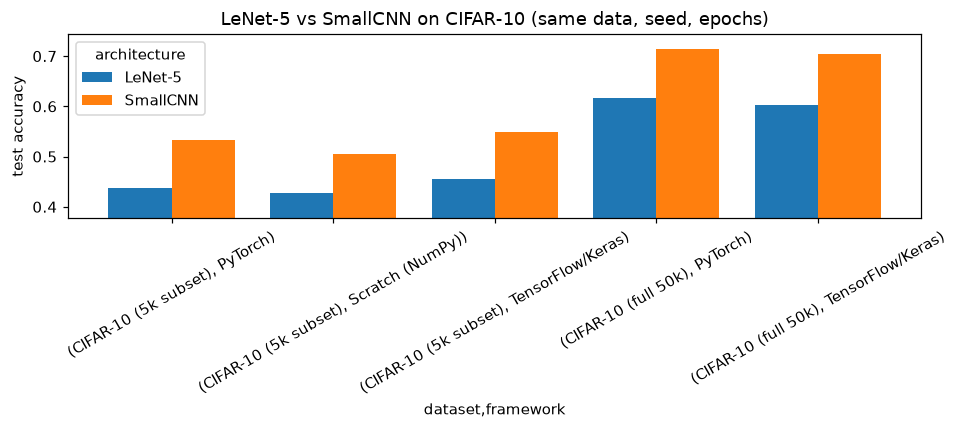

In [24]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_df = pivot.drop(columns="delta (LeNet - baseline)")
plot_df.plot(kind="bar", ax=ax, width=0.78)
ax.set_ylabel("test accuracy")
ax.set_title("LeNet-5 vs SmallCNN on CIFAR-10 (same data, seed, epochs)")
ax.set_ylim(plot_df.values.min() - 0.05, min(1.0, plot_df.values.max() + 0.03))
ax.legend(title="architecture")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

---

## 9. Mỗi thành phần nằm ở đâu

In [25]:
component_table = pd.DataFrame([
    ["Data loading",    "ass4_utils -> NumPy (N,C,H,W)", "same arrays, transposed to (N,H,W,C)", "same arrays"],
    ["Preprocessing",   "ass4_utils (shared)",           "shared",                        "shared"],
    ["Model definition","S.Sequential([...])",           "keras.Sequential([...])",       "nn.Module (LeNet5)"],
    ["C1 / C3 conv",    "S.Conv2D(k=5) im2col+matmul",   "keras.layers.Conv2D(5)",        "nn.Conv2d(5)"],
    ["Activation",      "S.ReLU (mask multiply)",        "activation='relu'",             "nn.ReLU"],
    ["S2 / S4 pooling", "S.MaxPool2D (argmax routing)",  "keras.layers.MaxPooling2D",     "nn.MaxPool2d"],
    ["Flatten",         "S.Flatten (reshape)",           "keras.layers.Flatten",          "nn.Flatten"],
    ["F5 / F6 / output","S.Dense (x@W+b)",               "keras.layers.Dense",            "nn.Linear"],
    ["Loss",            "S.SoftmaxCrossEntropy",         "SparseCategoricalCrossentropy", "nn.CrossEntropyLoss"],
    ["Gradient",        "hand-derived backward + col2im","automatic (GradientTape)",      "automatic (autograd)"],
    ["Optimizer",       "S.Adam (written out)",          "keras.optimizers.Adam",         "torch.optim.Adam"],
    ["Training loop",   "explicit for-loop",             "model.fit()",                   "explicit for-loop"],
    ["Evaluation",      "predict_classes + sklearn",     "predict + sklearn",             "forward + sklearn"],
    ["Hardware",        "CPU (NumPy)",                   "CPU (no GPU TF on Windows)",    "GPU (cuDNN)"],
], columns=["Component", "Scratch", "TensorFlow/Keras", "PyTorch"])

display(component_table)

,Component,Scratch,TensorFlow/Keras,PyTorch
0,Data loading,"ass4_utils -> NumPy (N,C,H,W)","same arrays, transposed to (N,H,W,C)",same arrays
1,Preprocessing,ass4_utils (shared),shared,shared
2,Model definition,S.Sequential([...]),keras.Sequential([...]),nn.Module (LeNet5)
3,C1 / C3 conv,S.Conv2D(k=5) im2col+matmul,keras.layers.Conv2D(5),nn.Conv2d(5)
4,Activation,S.ReLU (mask multiply),activation='relu',nn.ReLU
5,S2 / S4 pooling,S.MaxPool2D (argmax routing),keras.layers.MaxPooling2D,nn.MaxPool2d
6,Flatten,S.Flatten (reshape),keras.layers.Flatten,nn.Flatten
7,F5 / F6 / output,S.Dense (x@W+b),keras.layers.Dense,nn.Linear
8,Loss,S.SoftmaxCrossEntropy,SparseCategoricalCrossentropy,nn.CrossEntropyLoss
9,Gradient,hand-derived backward + col2im,automatic (GradientTape),automatic (autograd)


In [26]:
os.makedirs("results", exist_ok=True)
with open("results/07_cifar10_lenet.json", "w") as f:
    json.dump({"meta": {k: v for k, v in meta.items()},
               "results": [r.__dict__ for r in results],
               "full_results": [r.__dict__ for r in full_results],
               "component_table": component_table.to_dict(orient="records"),
               "baseline_comparison": pivot.reset_index().to_dict(orient="records")},
              f, indent=2, default=str)
print("saved results/07_cifar10_lenet.json")

saved results/07_cifar10_lenet.json


## Lưu lại mô hình đã huấn luyện

Tệp JSON ở trên ghi lại các mô hình **đạt** bao nhiêu điểm. Nó không ghi lại các
mô hình **là** gì — muốn có lại những con số này thì phải huấn luyện lại từ đầu.

`U.save_model` ghi từng nhánh theo định dạng gốc của framework tương ứng, vào
`results/models/<notebook>/`, kèm một tệp JSON đi cùng ghi rõ kiến trúc và điểm
số mà đúng bộ trọng số đó đạt được:

| nhánh | tệp | tự nạp lại được? |
|---|---|---|
| Scratch (NumPy) | `.npz`, mỗi tham số của mỗi tầng là một mảng | không |
| TensorFlow/Keras | `.keras`, đồ thị + trọng số | **được** |
| PyTorch | `.pt`, `state_dict` | không |

`.pt` và `.npz` chỉ chứa trọng số, nên nạp lại chúng đồng nghĩa với việc phải
dựng lại kiến trúc trước rồi truyền đối tượng mới vào
`U.load_model(..., model=...)`. Đây đúng là giao kèo mà `variants.py` dùng cho
`results/variant_cache/`.

In [27]:
# Weights are the model; metrics only describe it. Persist all three legs.
TAG = "07_cifar10_lenet"

by_fw = {r.framework: r for r in results}

for obj, fw, stem in [
    (scratch_model, "Scratch (NumPy)",  "lenet5_scratch"),
    (keras_model,   "TensorFlow/Keras", "lenet5_keras"),
    (torch_model,   "PyTorch",          "lenet5_torch"),
]:
    r = by_fw[fw]
    U.save_model(obj, f"{stem}_subset", TAG, architecture=r.model, dataset=r.dataset,
                 epochs=r.epochs, test_accuracy=r.test_accuracy, f1_macro=r.f1_macro)

# The full-data reruns — scratch NumPy is not rerun at this size, so two legs.
by_fw_full = {r.framework: r for r in full_results}

for obj, fw, stem in [
    (keras_full, "TensorFlow/Keras", "lenet5_keras"),
    (torch_full, "PyTorch",          "lenet5_torch"),
]:
    r = by_fw_full[fw]
    U.save_model(obj, f"{stem}_full", TAG, architecture=r.model, dataset=r.dataset,
                 epochs=r.epochs, test_accuracy=r.test_accuracy, f1_macro=r.f1_macro)

display(U.list_models(TAG)[["name", "framework", "n_params", "dataset", "test_accuracy"]])


saved results\models\07_cifar10_lenet\lenet5_scratch_subset.npz  (62,006 params, 227 KB)
saved results\models\07_cifar10_lenet\lenet5_keras_subset.keras  (62,006 params, 769 KB)
saved results\models\07_cifar10_lenet\lenet5_torch_subset.pt  (62,006 params, 247 KB)
saved results\models\07_cifar10_lenet\lenet5_keras_full.keras  (62,006 params, 769 KB)
saved results\models\07_cifar10_lenet\lenet5_torch_full.pt  (62,006 params, 247 KB)


,name,framework,n_params,dataset,test_accuracy
0,lenet5_keras_full,keras,62006,CIFAR-10 (full 50k),0.6032
1,lenet5_keras_subset,keras,62006,CIFAR-10 (5k subset),0.4545
2,lenet5_scratch_subset,scratch,62006,CIFAR-10 (5k subset),0.4270
3,lenet5_torch_full,torch,62006,CIFAR-10 (full 50k),0.6162
4,lenet5_torch_subset,torch,62006,CIFAR-10 (5k subset),0.4375


---

## 10. Notebook này cho thấy điều gì

Đây là chỗ việc giữ nguyên kiến trúc trả công. LeNet-5 được dựng cho chữ số ảnh
xám 32×32; CIFAR-10 là ảnh màu 32×32. Kích thước đầu vào khớp chính xác, còn độ
khó thì không.

Mục 8 định lượng cái giá đó. LeNet-5 mang khoảng một phần chín số tham số của
`SmallCNN`, và gần như toàn bộ phần nó có lại nằm ở phần đầu phân loại chứ không
nằm ở bộ trích xuất đặc trưng — C1 và C3 cộng lại chưa tới 3 nghìn trọng số. Sáu
bản đồ đặc trưng không đủ làm vốn từ thị giác cho mười lớp đối tượng chụp ở đủ
kiểu tư thế, ánh sáng và nền.

Bài học không phải là LeNet-5 dở. Bài học là **sức chứa của kiến trúc phải tương
xứng với độ khó của dữ liệu**. Cùng một mạng hoàn toàn đủ dùng cho chữ số thì lại
quá bé cho ảnh tự nhiên, và không lượng thời gian huấn luyện nào chữa được một
nút thắt biểu diễn hẹp đến thế. Nới rộng các bản đồ đặc trưng — đúng việc
`SmallCNN` làm với 32 và 64 kênh — mới là thứ khép được khoảng cách.

Hãy đối chiếu với `04_compare.ipynb`, nơi M1 → M4 giữ ngân sách tham số gần như
không đổi mà thay đổi **cơ chế** (BatchNorm, kết nối tắt, chú ý SE). Hai trục đó
— sức chứa và cơ chế — là hai cách cải thiện một CNN độc lập với nhau.